# 64-Neuron 4-Class — W/M-Information Analysis (Local)

Loads the 10 trained 64-neuron seeded pairs from Colab checkpoints and performs:
1. Results summary with statistical tests
2. Neuron utilization diagnostics (silent neuron detection)
3. W/M-information with time-shuffle null Z-scoring

No training — analysis only.

## 1. Imports & Path Setup

In [1]:
import sys
sys.path.insert(0, r"C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files")

from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import torch
from IPython.display import display
import matplotlib.pyplot as plt

import seeded_runs_common as seeded_runs_common
seeded_runs_common = importlib.reload(seeded_runs_common)

CHECKPOINT_ROOT = seeded_runs_common.CHECKPOINT_ROOT
DEVICE = seeded_runs_common.DEVICE
TASKS = seeded_runs_common.TASKS
build_seeded_pair = seeded_runs_common.build_seeded_pair
build_sampling_preview_rows = seeded_runs_common.build_sampling_preview_rows
get_pair_checkpoint_paths = seeded_runs_common.get_pair_checkpoint_paths
load_default_caches = seeded_runs_common.load_default_caches
read_manifest_rows = seeded_runs_common.read_manifest_rows

RUN_LABEL = "seeded_run_1_64n"
TASK_KEY = "4class"
MEM_DISTRIBUTION_FAMILY = "lognormal"
MASTER_SEEDS = [101, 202, 210, 340, 440, 550, 660, 710, 820, 930]

RUN_DIR = CHECKPOINT_ROOT / RUN_LABEL / f"{TASK_KEY}_{MEM_DISTRIBUTION_FAMILY}"
RESULT_STEM = RUN_DIR / f"{RUN_LABEL}_checkpoint_summary"
PAIR_STEM = RUN_DIR / f"{RUN_LABEL}_pair_summary"

TASK_DEF = TASKS[TASK_KEY]

# Set nb_recurrent to 64 for model building
seeded_runs_common.BASE_PRMS["nb_recurrent"] = 64

print(f"Device: {DEVICE}")
print(f"Run directory: {RUN_DIR}")
print(f"Checkpoints found: {(RUN_DIR / '4class_seed101_hom_geommean_lognormal.pt').exists()}")

Device: cuda
Run directory: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Checkpoints\SeededRuns\seeded_run_1_64n\4class_lognormal
Checkpoints found: True


## 2. Results Summary from Saved Checkpoints

In [2]:
checkpoint_rows = read_manifest_rows(RESULT_STEM)
pair_rows = read_manifest_rows(PAIR_STEM)

checkpoint_df = pd.DataFrame(checkpoint_rows)
pair_df = pd.DataFrame(pair_rows)

if not checkpoint_df.empty:
    checkpoint_df = checkpoint_df.sort_values(["pair_seed", "pair_role"]).reset_index(drop=True)
if not pair_df.empty:
    pair_df = pair_df.sort_values("pair_seed").reset_index(drop=True)

paired_acc_df = checkpoint_df.pivot(
    index="pair_seed", columns="pair_role", values="final_test_acc"
).reset_index().sort_values("pair_seed").reset_index(drop=True)
paired_acc_df.columns.name = None
paired_acc_df["hetero_minus_hom"] = paired_acc_df["heterogeneous_sampled"] - paired_acc_df["homogeneous_anchor"]

print(f"Loaded {len(paired_acc_df)} seeds from checkpoints.\n")

display(checkpoint_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss"]])
display(paired_acc_df)

from scipy import stats

diffs = paired_acc_df["hetero_minus_hom"].values
homo = paired_acc_df["homogeneous_anchor"].values
hetero = paired_acc_df["heterogeneous_sampled"].values
n = len(diffs)
mean_diff = np.mean(diffs)
sd_diff = np.std(diffs, ddof=1)

print(f"\n{'='*60}")
print(f"  4-Class × 64 Neurons — {n} Seeds")
print(f"{'='*60}")
for i, row in paired_acc_df.iterrows():
    print(f"  Seed {int(row['pair_seed'])}:  homo={row['homogeneous_anchor']*100:.1f}%  "
          f"hetero={row['heterogeneous_sampled']*100:.1f}%  Δ={row['hetero_minus_hom']*100:+.1f}pp")
print(f"  ──────────────────────────────────")
print(f"  Hetero > Homo: {int(np.sum(diffs>0))}/{n}")
print(f"  Mean Δacc:     {mean_diff*100:+.2f} pp")
print(f"  SD Δacc:       {sd_diff*100:.2f} pp")

if n >= 2:
    t_stat, p_ttest = stats.ttest_rel(hetero, homo, alternative="greater")
    w_stat, p_wilcoxon = stats.wilcoxon(hetero, homo, alternative="greater")
    cohens_d = mean_diff / sd_diff if sd_diff > 0 else 0.0
    ci = stats.t.interval(0.95, df=n-1, loc=mean_diff, scale=sd_diff/np.sqrt(n))
    print(f"  95% CI:        [{ci[0]*100:+.2f}, {ci[1]*100:+.2f}] pp")
    print(f"  Cohen's d:     {cohens_d:.3f}")
    print(f"  t-test p:      {p_ttest:.6f}  {'★' if p_ttest<0.05 else '—'} {'significant' if p_ttest<0.05 else ''}")
    print(f"  Wilcoxon p:    {p_wilcoxon:.6f}  {'★' if p_wilcoxon<0.05 else '—'} {'significant' if p_wilcoxon<0.05 else ''}")

print(f"\n  ── vs 32-neuron ──")
print(f"  32n Mean Δ:    -5.11 pp (hetero WORSE)")
print(f"  64n Mean Δ:    {mean_diff*100:+.2f} pp")
print(f"\n  ── Perez-Nieves benchmark: +3–8 pp ──")
if mean_diff >= 0.03:
    print(f"  ✓ Within/above Perez-Nieves range")
elif mean_diff >= 0.02:
    print(f"  ~ Close to benchmark")
else:
    print(f"  — Below benchmark")

Loaded 10 seeds from checkpoints.



,pair_seed,pair_role,final_test_acc,final_test_loss
0,101,heterogeneous_sampled,0.662102,0.934457
1,101,homogeneous_anchor,0.581714,1.054689
2,202,heterogeneous_sampled,0.694346,0.969237
3,202,homogeneous_anchor,0.569788,1.001398
4,210,heterogeneous_sampled,0.715548,0.892574
5,210,homogeneous_anchor,0.508834,1.085149
6,340,heterogeneous_sampled,0.674028,1.110911
7,340,homogeneous_anchor,0.581714,1.054285
8,440,heterogeneous_sampled,0.731007,0.816314
9,440,homogeneous_anchor,0.614841,0.977494


,pair_seed,heterogeneous_sampled,homogeneous_anchor,hetero_minus_hom
0,101,0.662102,0.581714,0.080389
1,202,0.694346,0.569788,0.124558
2,210,0.715548,0.508834,0.206714
3,340,0.674028,0.581714,0.092314
4,440,0.731007,0.614841,0.116166
5,550,0.689488,0.582155,0.107332
6,660,0.754859,0.526502,0.228357
7,710,0.576413,0.528710,0.047703
8,820,0.704947,0.530919,0.174028
9,930,0.684629,0.559187,0.125442



  4-Class × 64 Neurons — 10 Seeds
  Seed 101:  homo=58.2%  hetero=66.2%  Δ=+8.0pp
  Seed 202:  homo=57.0%  hetero=69.4%  Δ=+12.5pp
  Seed 210:  homo=50.9%  hetero=71.6%  Δ=+20.7pp
  Seed 340:  homo=58.2%  hetero=67.4%  Δ=+9.2pp
  Seed 440:  homo=61.5%  hetero=73.1%  Δ=+11.6pp
  Seed 550:  homo=58.2%  hetero=68.9%  Δ=+10.7pp
  Seed 660:  homo=52.7%  hetero=75.5%  Δ=+22.8pp
  Seed 710:  homo=52.9%  hetero=57.6%  Δ=+4.8pp
  Seed 820:  homo=53.1%  hetero=70.5%  Δ=+17.4pp
  Seed 930:  homo=55.9%  hetero=68.5%  Δ=+12.5pp
  ──────────────────────────────────
  Hetero > Homo: 10/10
  Mean Δacc:     +13.03 pp
  SD Δacc:       5.67 pp
  95% CI:        [+8.98, +17.08] pp
  Cohen's d:     2.299
  t-test p:      0.000024  ★ significant
  Wilcoxon p:    0.000977  ★ significant

  ── vs 32-neuron ──
  32n Mean Δ:    -5.11 pp (hetero WORSE)
  64n Mean Δ:    +13.03 pp

  ── Perez-Nieves benchmark: +3–8 pp ──
  ✓ Within/above Perez-Nieves range


## 3. Load Caches for Trace Extraction

In [3]:
train_cache, test_cache = load_default_caches()

Pre-loading SHD training data into RAM...
  SHDCache: 8156 samples loaded from shd_train.h5
Pre-loading SHD test data into RAM...
  SHDCache: 2264 samples loaded from shd_test.h5


## 4. Neuron Utilization Diagnostics

Check that all neurons are active. Silent neurons must be excluded before W/M computation.

### 4.1 Extract Spike Traces

In [6]:
def extract_hidden_traces(model, prms, data_cache, n_batches=8, layer_idx=0):
    """Extract hidden-layer membrane potential and spike traces from test data."""
    mem_list, spk_list = [], []
    model.eval()
    
    with torch.no_grad():
        units, times, labels = data_cache.units, data_cache.times, data_cache.labels
        class_list = prms.get("class_list", list(range(20)))
        label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
        sample_idx = np.where(np.isin(label_arr, class_list))[0]
        
        batch_size = min(prms.get("batch_size", 256), len(sample_idx))
        n_batches = min(n_batches, len(sample_idx) // max(batch_size, 1))
        
        for b in range(n_batches):
            bi = sample_idx[b * batch_size:(b + 1) * batch_size]
            actual_bs = len(bi)
            
            t_arrays = [np.round(times[idx] * (1.0 / prms["time_step"])).astype(np.int64) for idx in bi]
            u_arrays = [units[idx] for idx in bi]
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), [len(a) for a in t_arrays])
            valid = all_ts < prms["nb_steps"]
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            
            index_tensor = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            values = torch.ones(all_ts.size, dtype=torch.float32)
            x_batch = torch.sparse_coo_tensor(
                index_tensor, values,
                torch.Size([actual_bs, prms["nb_steps"], prms["nb_inputs"]])
            ).to_dense().clamp_(max=1.0).to(DEVICE)
            
            layer_recs = model(0, 0, x_batch)
            # RSNN returns (spikes, membrane, ...) per layer; use index access
            layer_out = layer_recs[layer_idx]
            spk, mem = layer_out[0], layer_out[1]
            
            mem_flat = mem.permute(2, 0, 1).reshape(mem.shape[2], -1).cpu().numpy()
            spk_flat = spk.permute(2, 0, 1).reshape(spk.shape[2], -1).cpu().numpy()
            mem_list.append(mem_flat)
            spk_list.append(spk_flat)
    
    mem_all = np.concatenate(mem_list, axis=1)
    spk_all = np.concatenate(spk_list, axis=1)
    return mem_all, spk_all

In [7]:
# Run extraction for seed 101
WM_SEED = 101
WM_N_BATCHES = 8

wm_pair = build_seeded_pair(
    master_seed=WM_SEED, task_key=TASK_KEY, mem_distribution_family=MEM_DISTRIBUTION_FAMILY)
paths = get_pair_checkpoint_paths(
    master_seed=WM_SEED, run_label=RUN_LABEL, task_key=TASK_KEY,
    mem_distribution_family=MEM_DISTRIBUTION_FAMILY, checkpoint_root=CHECKPOINT_ROOT)

homo_ckpt = torch.load(paths["homogeneous_anchor"], map_location="cpu")
hetero_ckpt = torch.load(paths["heterogeneous_sampled"], map_location="cpu")
wm_pair["hom_model"].load_state_dict(homo_ckpt["model_state_dict"])
wm_pair["hetero_model"].load_state_dict(hetero_ckpt["model_state_dict"])

print(f"Seed {WM_SEED}: Homo acc={homo_ckpt['history']['test_acc'][-1]:.3f}, "
      f"Hetero acc={hetero_ckpt['history']['test_acc'][-1]:.3f}")

print(f"Extracting traces from {WM_N_BATCHES} test batches...")
homo_mem, homo_spk = extract_hidden_traces(
    wm_pair["hom_model"], wm_pair["hom_prms"], test_cache, n_batches=WM_N_BATCHES)
hetero_mem, hetero_spk = extract_hidden_traces(
    wm_pair["hetero_model"], wm_pair["hetero_prms"], test_cache, n_batches=WM_N_BATCHES)

# Temporal downsampling
WM_STRIDE = 4
homo_mem = homo_mem[:, ::WM_STRIDE]
hetero_mem = hetero_mem[:, ::WM_STRIDE]
homo_spk = homo_spk[:, ::WM_STRIDE]
hetero_spk = hetero_spk[:, ::WM_STRIDE]

print(f"  Homo mem:  {homo_mem.shape}  spk: {homo_spk.shape}  (stride={WM_STRIDE})")
print(f"  Hetero mem: {hetero_mem.shape}  spk: {hetero_spk.shape}  (stride={WM_STRIDE})")

Seed 101: Homo acc=0.582, Hetero acc=0.662
Extracting traces from 8 test batches...
  Homo mem:  (64, 512000)  spk: (64, 512000)  (stride=4)
  Hetero mem: (64, 512000)  spk: (64, 512000)  (stride=4)


### 4.2 Silent Neuron Detection


  Homogeneous — Neuron Utilization (Seed 101)
  Total: 64  |  Silent: 39  |  Low: 0  |  Active: 25
  Mean firing rate: -43.0007%  |  Max: 936.8335%
  Silent indices: [0, 2, 3, 4, 5, 8, 11, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27, 29, 31, 33, 34, 35, 36, 37, 39, 42, 44, 46, 48, 49, 51, 55, 57, 58, 59, 60, 61, 62, 63]

  Heterogeneous — Neuron Utilization (Seed 101)
  Total: 64  |  Silent: 31  |  Low: 0  |  Active: 33
  Mean firing rate: 73.6665%  |  Max: 3361.4525%
  Silent indices: [0, 4, 5, 8, 11, 12, 13, 15, 17, 18, 19, 22, 24, 28, 31, 34, 35, 36, 38, 42, 46, 47, 49, 50, 51, 53, 55, 57, 58, 60, 63]


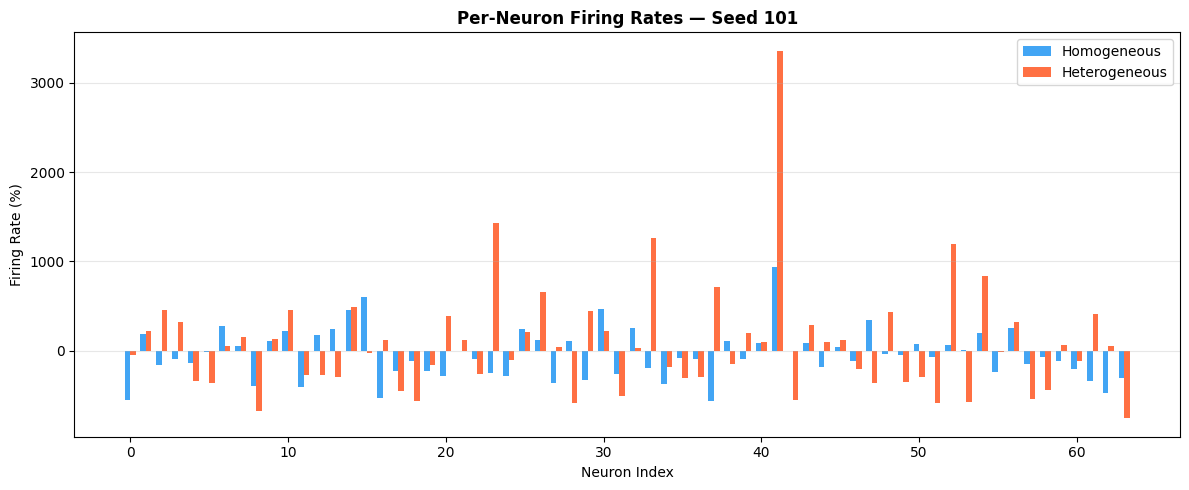


Silent overlap: homo-only=16, hetero-only=8, both=23


In [8]:
for name, spk_data in [("Homogeneous", homo_spk), ("Heterogeneous", hetero_spk)]:
    n_neurons = spk_data.shape[0]
    spike_rates = spk_data.mean(axis=1)
    silent = spike_rates < 1e-9
    low = (spike_rates >= 1e-9) & (spike_rates < 1e-4)
    active = spike_rates >= 1e-4
    
    print(f"\n{'='*55}")
    print(f"  {name} — Neuron Utilization (Seed {WM_SEED})")
    print(f"{'='*55}")
    print(f"  Total: {n_neurons}  |  Silent: {silent.sum()}  |  Low: {low.sum()}  |  Active: {active.sum()}")
    print(f"  Mean firing rate: {spike_rates.mean()*100:.4f}%  |  Max: {spike_rates.max()*100:.4f}%")
    if silent.sum() > 0:
        print(f"  Silent indices: {list(np.where(silent)[0])}")

# Side-by-side firing rate comparison
fig, ax = plt.subplots(figsize=(12, 5))
homo_rates = homo_spk.mean(axis=1) * 100
hetero_rates = hetero_spk.mean(axis=1) * 100
x = np.arange(len(homo_rates))
width = 0.35
ax.bar(x - width/2, homo_rates, width, color="#2196F3", alpha=0.85, label="Homogeneous")
ax.bar(x + width/2, hetero_rates, width, color="#FF5722", alpha=0.85, label="Heterogeneous")
ax.set_xlabel("Neuron Index"); ax.set_ylabel("Firing Rate (%)")
ax.set_title(f"Per-Neuron Firing Rates — Seed {WM_SEED}", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

homo_silent = set(np.where(homo_rates < 1e-9)[0])
hetero_silent = set(np.where(hetero_rates < 1e-9)[0])
print(f"\nSilent overlap: homo-only={len(homo_silent-hetero_silent)}, "
      f"hetero-only={len(hetero_silent-homo_silent)}, both={len(homo_silent & hetero_silent)}")

## 5. W/M-Information with Time-Shuffle Null Z-Scoring

Non-parametric null: each neuron's time series is independently permuted to destroy temporal correlations while preserving marginal distributions.

In [12]:
import time as time_module
import json
import warnings

# ── Filter to ACTIVE neurons only ──────────────────────────────────
homo_fr = homo_spk.mean(axis=1)
hetero_fr = hetero_spk.mean(axis=1)
homo_active = np.where(homo_fr >= 1e-9)[0]   # 25 neurons
hetero_active = np.where(hetero_fr >= 1e-9)[0]  # 33 neurons
print(f"Active neurons — Homo: {len(homo_active)}, Hetero: {len(hetero_active)}")

# Only sample from active subset; cap k at active count
ACTIVE_TRACES = {"homo": homo_mem[homo_active, :], "hetero": hetero_mem[hetero_active, :]}
MAX_ACTIVE = min(len(homo_active), len(hetero_active))  # 25

WM_SUBSET_SIZES = [k for k in [2, 4, 8, 16, 32, 64] if k <= MAX_ACTIVE]
if MAX_ACTIVE not in WM_SUBSET_SIZES:
    WM_SUBSET_SIZES.append(MAX_ACTIVE)
WM_N_SUBSETS = {k: 50 if k <= 4 else (30 if k <= 8 else (20 if k <= 16 else 10)) for k in WM_SUBSET_SIZES}
WM_N_SUBSETS[MAX_ACTIVE] = 1
N_NULL = 100

print(f"W/M subset sizes: {WM_SUBSET_SIZES}")

# Checkpoint file for intermediate results
_WM_CHECKPOINT = RUN_DIR / f"wm_zscore_seed{WM_SEED}_active.json"

# Try loading partial progress
wm_results = {"k": [], "role": [], "W_bits": [], "M_bits": [], "z_W": [], "z_M": [], "seed": []}
completed_ks = set()
if _WM_CHECKPOINT.exists():
    with open(_WM_CHECKPOINT, "r") as f:
        saved = json.load(f)
    wm_results = saved
    df_saved = pd.DataFrame(saved)
    for k in WM_SUBSET_SIZES:
        roles_done = df_saved[df_saved["k"] == k]["role"].unique()
        if len(roles_done) == 2:
            completed_ks.add(k)
    print(f"  Resuming from checkpoint: {len(completed_ks)}/{len(WM_SUBSET_SIZES)} k values already done.")

wm_rng = np.random.default_rng(WM_SEED + 1)

print(f"Seed {WM_SEED} — W/M + Time-Shuffle Z-scores (N_null={N_NULL}, active-only)")
print(f"{'k':>3}  {'role':>7}  {'W':>8}  {'M':>8}  {'z_W':>8}  {'z_M':>8}  {'time':>8}")
print("-" * 65)

for k in WM_SUBSET_SIZES:
    if k in completed_ks:
        for role in ["homo", "hetero"]:
            saved_row = df_saved[(df_saved["k"] == k) & (df_saved["role"] == role)]
            if not saved_row.empty:
                r = saved_row.iloc[0]
                print(f"{k:>3}  {role:>7}  {r['W_bits']:>8.4f}  {r['M_bits']:>8.4f}  "
                      f"{r['z_W']:>8.1f}  {r['z_M']:>8.1f}  {'(cached)':>8}")
        continue
    
    n_subsets = WM_N_SUBSETS.get(k, 10)
    for role, traces in [("homo", ACTIVE_TRACES["homo"]), ("hetero", ACTIVE_TRACES["hetero"])]:
        t0 = time_module.perf_counter()
        w_vals, m_vals, zw_vals, zm_vals = [], [], [], []
        
        for _ in range(n_subsets):
            idx = wm_rng.choice(traces.shape[0], k, replace=False)
            data = traces[idx, :].copy().astype(np.float64)
            
            from wimfo.utils.utils_gauss import get_cov
            cov_obs = get_cov(data, t=1)
            
            from wimfo.W_M_Info import W_M_calculator
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                w_obs, m_obs = W_M_calculator(cov_obs, option="distr", type="gaussian", optimiser="Adam")
            
            if np.isnan(w_obs) or np.isnan(m_obs):
                zw_vals.append(np.nan); zm_vals.append(np.nan)
                w_vals.append(np.nan); m_vals.append(np.nan)
                continue
            w_vals.append(w_obs); m_vals.append(m_obs)
            
            w_null, m_null = [], []
            for _ in range(N_NULL):
                shuffled = data.copy()
                for j in range(k):
                    wm_rng.shuffle(shuffled[j, :])
                cov_null = get_cov(shuffled, t=1)
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    w_n, m_n = W_M_calculator(cov_null, option="distr", type="gaussian", optimiser="Adam")
                w_null.append(w_n if not np.isnan(w_n) else np.nan)
                m_null.append(m_n if not np.isnan(m_n) else np.nan)
            
            w_null_arr = np.array(w_null); m_null_arr = np.array(m_null)
            w_null_valid = w_null_arr[~np.isnan(w_null_arr)]
            m_null_valid = m_null_arr[~np.isnan(m_null_arr)]
            if len(w_null_valid) > 1 and w_null_valid.std() > 0:
                z_w = (w_obs - w_null_valid.mean()) / w_null_valid.std()
            else:
                z_w = np.nan
            if len(m_null_valid) > 1 and m_null_valid.std() > 0:
                z_m = (m_obs - m_null_valid.mean()) / m_null_valid.std()
            else:
                z_m = np.nan
            zw_vals.append(z_w); zm_vals.append(z_m)
        
        w_valid = np.array(w_vals)[~np.isnan(w_vals)]
        m_valid = np.array(m_vals)[~np.isnan(m_vals)]
        zw_valid = np.array(zw_vals)[~np.isnan(zw_vals)]
        zm_valid = np.array(zm_vals)[~np.isnan(zm_vals)]
        n_valid = len(w_valid)
        w_mean = np.nanmean(w_valid) if n_valid > 0 else np.nan
        m_mean = np.nanmean(m_valid) if n_valid > 0 else np.nan
        zw_mean = np.nanmean(zw_valid) if n_valid > 0 else np.nan
        zm_mean = np.nanmean(zm_valid) if n_valid > 0 else np.nan
        elapsed = time_module.perf_counter() - t0
        
        wm_results["k"].append(k); wm_results["role"].append(role)
        wm_results["W_bits"].append(w_mean); wm_results["M_bits"].append(m_mean)
        wm_results["z_W"].append(zw_mean); wm_results["z_M"].append(zm_mean)
        wm_results["seed"].append(WM_SEED)
        
        print(f"{k:>3}  {role:>7}  {w_mean:>8.4f}  {m_mean:>8.4f}  {zw_mean:>8.1f}  {zm_mean:>8.1f}  {elapsed:>6.1f}s  ({n_valid}/{n_subsets} ok)")
    
    # Save checkpoint after each k
    with open(_WM_CHECKPOINT, "w") as f:
        json.dump(wm_results, f, indent=2)

wm_df = pd.DataFrame(wm_results)
print(f"\n✓ W/M + Time-Shuffle Z-score sweep complete.  Checkpoint: {_WM_CHECKPOINT}")
display(wm_df[["k", "role", "W_bits", "M_bits", "z_W", "z_M"]])

Active neurons — Homo: 25, Hetero: 33
W/M subset sizes: [2, 4, 8, 16, 25]
Seed 101 — W/M + Time-Shuffle Z-scores (N_null=100, active-only)
  k     role         W         M       z_W       z_M      time
-----------------------------------------------------------------
  2     homo    4.0142    0.0049  1228363.8    4908.7  1143.7s  (50/50 ok)
  2   hetero    5.4944    0.0213  1624454.7   20131.5  1263.1s  (48/50 ok)
  4     homo    7.4283    0.0285  1237177.6    9393.6  1782.7s  (39/50 ok)
  4   hetero    9.4078    0.0879  1504368.8   28971.6   819.0s  (15/50 ok)
  8     homo   13.3678    0.0555  965511.8    8184.2   119.8s  (1/30 ok)
  8   hetero       nan       nan       nan       nan    12.2s  (0/30 ok)
 16     homo       nan       nan       nan       nan    17.5s  (0/20 ok)
 16   hetero       nan       nan       nan       nan    17.5s  (0/20 ok)
 25     homo       nan       nan       nan       nan     1.5s  (0/1 ok)
 25   hetero       nan       nan       nan       nan     1.6s  (0/1 

,k,role,W_bits,M_bits,z_W,z_M
0,2,homo,4.014193,0.004916,1.228364e+06,4908.697496
1,2,hetero,5.494365,0.021302,1.624455e+06,20131.540900
2,4,homo,7.428278,0.028503,1.237178e+06,9393.630794
3,4,hetero,9.407831,0.087893,1.504369e+06,28971.601922
4,8,homo,13.367766,0.055534,9.655118e+05,8184.168385
5,8,hetero,NaN,NaN,NaN,NaN
6,16,homo,NaN,NaN,NaN,NaN
7,16,hetero,NaN,NaN,NaN,NaN
8,25,homo,NaN,NaN,NaN,NaN
9,25,hetero,NaN,NaN,NaN,NaN


### 5.1 Plot W/M vs Subset Size

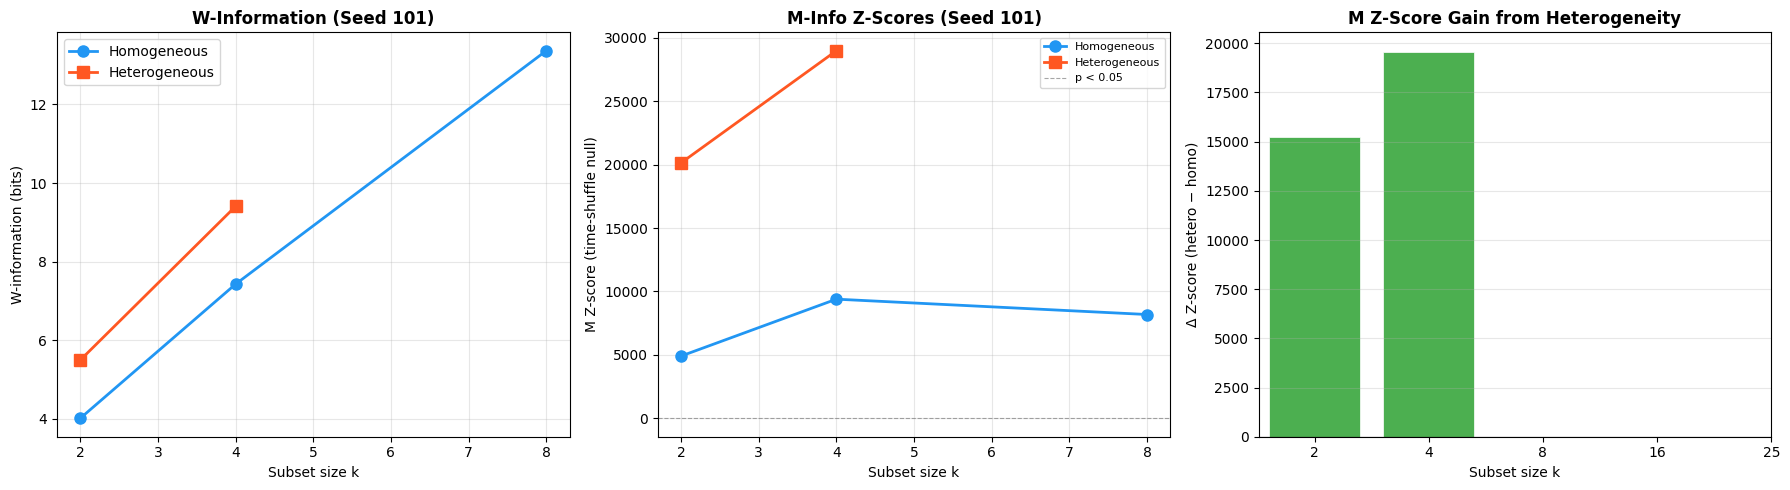


── W/M + Z-Score Summary (Seed 101) ──
  k          ΔW          ΔM        Δz_M     W_ratio
  2    +1.48017    +0.01639    +15222.8       1.369x
  4    +1.97955    +0.05939    +19578.0       1.266x
  8        +nan        +nan        +nan         nanx
 16        +nan        +nan        +nan         infx
 25        +nan        +nan        +nan         infx


In [13]:
homo = wm_df[wm_df["role"] == "homo"].sort_values("k")
hetero = wm_df[wm_df["role"] == "hetero"].sort_values("k")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(homo["k"], homo["W_bits"], "o-", color="#2196F3", lw=2, ms=8, label="Homogeneous")
ax.plot(hetero["k"], hetero["W_bits"], "s-", color="#FF5722", lw=2, ms=8, label="Heterogeneous")
ax.set_xlabel("Subset size k"); ax.set_ylabel("W-information (bits)")
ax.set_title(f"W-Information (Seed {WM_SEED})", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(homo["k"], homo["z_M"], "o-", color="#2196F3", lw=2, ms=8, label="Homogeneous")
ax.plot(hetero["k"], hetero["z_M"], "s-", color="#FF5722", lw=2, ms=8, label="Heterogeneous")
ax.axhline(y=1.96, color="gray", linestyle="--", lw=0.8, alpha=0.7, label="p < 0.05")
ax.set_xlabel("Subset size k"); ax.set_ylabel("M Z-score (time-shuffle null)")
ax.set_title(f"M-Info Z-Scores (Seed {WM_SEED})", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
delta_z = hetero["z_M"].values - homo["z_M"].values
colors = ["#4CAF50" if d > 0 else "#F44336" for d in delta_z]
ax.bar(range(len(WM_SUBSET_SIZES)), delta_z, color=colors, edgecolor="white", lw=0.5)
ax.set_xticks(range(len(WM_SUBSET_SIZES))); ax.set_xticklabels(WM_SUBSET_SIZES)
ax.set_xlabel("Subset size k"); ax.set_ylabel("Δ Z-score (hetero − homo)")
ax.set_title(f"M Z-Score Gain from Heterogeneity", fontweight="bold")
ax.axhline(y=0, color="black", lw=0.8); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print(f"\n── W/M + Z-Score Summary (Seed {WM_SEED}) ──")
print(f"{'k':>3}  {'ΔW':>10}  {'ΔM':>10}  {'Δz_M':>10}  {'W_ratio':>10}")
for i, k in enumerate(WM_SUBSET_SIZES):
    dw = hetero["W_bits"].values[i] - homo["W_bits"].values[i]
    dm = hetero["M_bits"].values[i] - homo["M_bits"].values[i]
    dz = delta_z[i]
    wr = hetero["W_bits"].values[i] / homo["W_bits"].values[i] if homo["W_bits"].values[i] > 0 else float("inf")
    print(f"{k:>3}  {dw:>+10.5f}  {dm:>+10.5f}  {dz:>+10.1f}  {wr:>10.3f}x")